# Avance 3. Baseline


El propósito de este notebook es establecer un modelo de referencia (baseline) para el pronóstico de la serie temporal de casos de depresión. Un modelo de referencia es fundamental en cualquier proyecto de machine learning porque:

1. Establece un punto de comparación: Sirve como una medida de rendimiento mínima que cualquier modelo más complejo (como SARIMA o modelos de machine learning) debe superar para justificar su complejidad.

2. Valida el entendimiento de los datos: Un buen modelo base demuestra que se han comprendido las características principales de la serie, como la tendencia y la estacionalidad.

## Librerías y Carga de Datos

* Se define si se utilizará Plotly para las gráficas y se importan las librerías necesarias para análisis de datos, visualización y modelado de series temporales.

Recomendaciones:  Para un mejor entendimiento de las gráficas o su uso local cambiar el valor de `USE_PLOTRLY` a `True`

In [1]:
USE_PLOTLY = False

### Librerías

In [2]:
import sys
sys.path.append('../../')

In [3]:
import pandas as pd
import numpy as np
from tabulate import tabulate
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, f_classif
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# !pip install holidays
from src.utils import helpers as func
# !pip install prince
import prince as pr
import plotly.express as px

### Carga de Datos

* Se carga el conjunto de datos procesado utilizando una función personalizada, preparando el DataFrame para el análisis.

In [4]:
# path = '../../data/processed/df_entidades_acum.parquet'
path = '../../data/processed/df_acumulado.parquet'
df = func.load_data(path)

Cargando datos desde: ../../data/processed/df_acumulado.parquet
Dimensiones del DataFrame: (573, 11)

Primeras filas del DataFrame:


,fecha,valor_acumulado,semana,rolling_mean,rolling_std,upper_bound,lower_bound,is_outlier,valor_acumulado_corregido,mes,año
0,2014-01-06,131.0,2,NaN,NaN,NaN,NaN,False,131.0,1,2014
1,2014-01-13,789.0,3,NaN,NaN,NaN,NaN,False,789.0,1,2014
2,2014-01-20,1722.0,4,880.666667,799.451270,1999.898445,-238.565112,False,1722.0,1,2014
3,2014-01-27,2745.0,5,1346.750000,1137.987807,2939.932930,-246.432930,False,2745.0,1,2014
4,2014-02-03,3896.0,6,2288.000000,1336.895658,4159.653921,416.346079,False,3896.0,2,2014


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 573 entries, 0 to 572
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   fecha                      573 non-null    datetime64[ns]
 1   valor_acumulado            573 non-null    float64       
 2   semana                     573 non-null    UInt32        
 3   rolling_mean               571 non-null    float64       
 4   rolling_std                571 non-null    float64       
 5   upper_bound                571 non-null    float64       
 6   lower_bound                571 non-null    float64       
 7   is_outlier                 573 non-null    bool          
 8   valor_acumulado_corregido  573 non-null    float64       
 9   mes                        573 non-null    int32         
 10  año                        573 non-null    int32         
dtypes: UInt32(1), bool(1), datetime64[ns](1), float64(6), int32(2)
memory u

None

## Análisis de la Serie Temporal

### Serie Original

* Se seleccionan las columnas relevantes y se grafica la serie temporal acumulada para observar su comportamiento general.

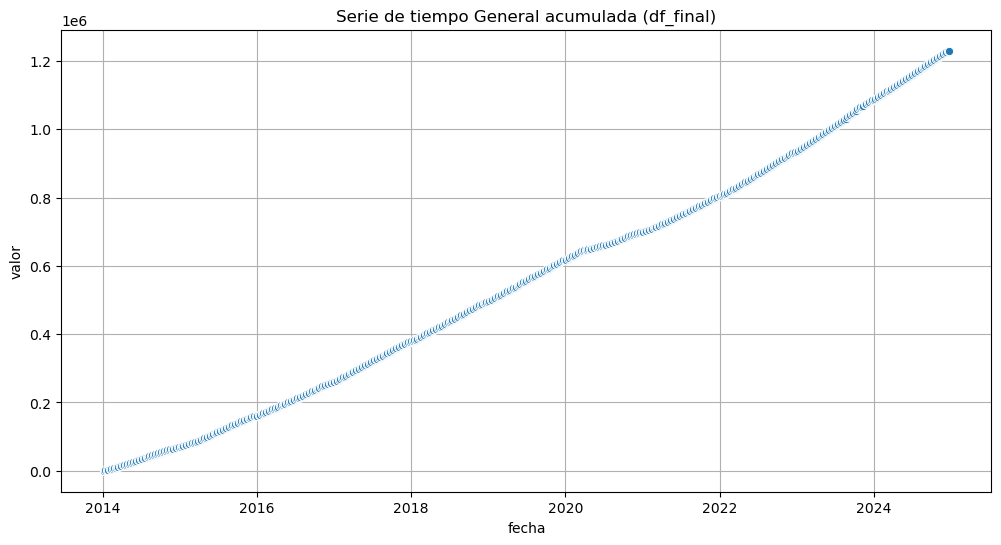

In [5]:
# Dataframe con las columnas necesarias para el análisis de series temporales
df_filtrado = df[['fecha', 'valor_acumulado_corregido']].copy()
df_filtrado.rename(columns={'valor_acumulado_corregido': 'valor'}, inplace=True)
x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General acumulada (df_final)'
# Gráfica de línea con plotly / seaborn según selección del usuario
func.plot_timeseries(df_filtrado, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)

#### Descripción de gráfico
Se realizaron las correcciones pertinentes al dataset para considerar los valores acumulados de todos los años pasados y se corrigieron los valores atípicos con interpolación. con ellos, se obtiene el gráfico mostrado arriba, en el cual, se puede confirmar que la serie temporal de casos de depresión exhibe una **fuerte y consistente tendencia de crecimiento** desde 2014. Esto valida que el ritmo constante de acumulación de casos a lo largo del tiempo es el patrón "normal". La serie es altamente predecible en su tendencia.

#### Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

* Se descompone la serie en sus componentes de tendencia, estacionalidad y ruido para identificar patrones subyacentes.

In [6]:
ts_data = df_filtrado.set_index('fecha')['valor']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data.head())

# Mostrar información de la serie temporal
print("\nInformación de la serie temporal:")
ts_data.info()

Serie temporal preparada para descomposición:


fecha
2014-01-06     131.0
2014-01-13     789.0
2014-01-20    1722.0
2014-01-27    2745.0
2014-02-03    3896.0
Name: valor, dtype: float64


Información de la serie temporal:
<class 'pandas.core.series.Series'>
DatetimeIndex: 573 entries, 2014-01-06 to 2024-12-23
Series name: valor
Non-Null Count  Dtype  
--------------  -----  
573 non-null    float64
dtypes: float64(1)
memory usage: 9.0 KB


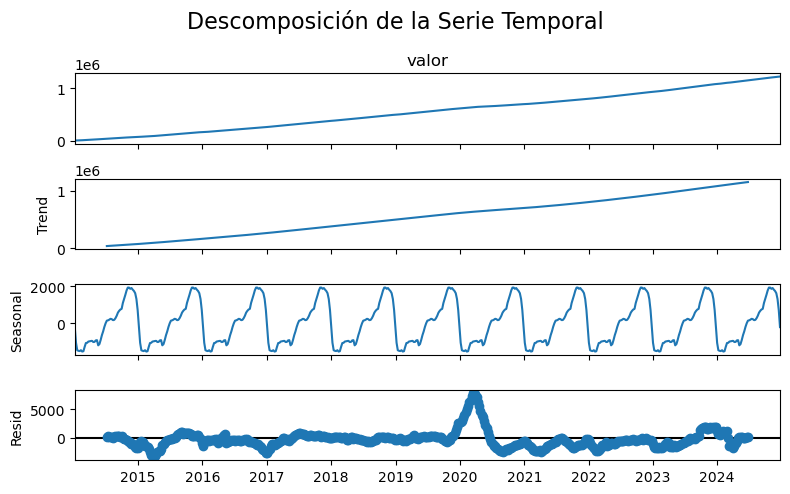

In [7]:
# Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

func.show_decomposition(ts_data, model='additive', figsize=(8, 5))

##### **Análisis de la Descomposición de la Serie Acumulada**

**Tendencia (Trend):** Muestra un **crecimiento lineal y casi perfecto** a lo largo de toda la década (2014-2024). Al corregir los valores atípicos de la serie acumulada, se confirma que la fuerza dominante es una **tendencia alcista ininterrumpida**, indicando un aumento constante y predecible del número total de casos.

**Estacionalidad (Seasonal):** Revela un patrón **anual, cíclico y muy bien definido**, con un pico que se repite anualmente (sube y baja) pero que no tiene grandes variaciones en su amplitud. Este patrón confirma la **influencia de los ciclos anuales** (probablemente laborales o estacionales) en el reporte de casos.

**Residuos (Resid):** El ruido es ahora mucho más controlado y disperso alrededor de cero. El pico anómalo de 2020 (probablemente un efecto de la pandemia o un cambio en el reporte) que antes dominaba la gráfica **ha sido tratado y disminuido**, dejando un ruido residual manejable.

La serie de tiempo es **altamente predecible**. Está dominada por una **tendencia de crecimiento lineal** y una **estacionalidad anual clara**. Al corregir los valores atípicos, el modelo de descomposición es robusto y los componentes quedan bien separados, lo que es ideal para aplicar modelos de pronóstico como SARIMA.

#### Pruebas de estacionaridad

* Se aplican pruebas estadísticas para determinar si la serie es estacionaria, es decir, si sus propiedades estadísticas son constantes en el tiempo.

##### Análisis de Resultados: Prueba ADF

In [8]:
estadistico_adf, p_value_adf, crit_val_adf = func.adf_test(ts_data)

Resultados de la Prueba ADF
╒═════════════════╤════════════════╤══════════════════════════╕
│ Métrica         │   Valor Prueba │   Nivel de Significancia │
╞═════════════════╪════════════════╪══════════════════════════╡
│ Estadístico ADF │        3.33816 │                 -2.86663 │
├─────────────────┼────────────────┼──────────────────────────┤
│ p-value         │        1       │                  0.05    │
╘═════════════════╧════════════════╧══════════════════════════╛


Los resultados de la Prueba de Dickey-Fuller Aumentada (ADF) confirman que la serie de tiempo es **no estacionaria**.

Dado que el **Estadístico ADF ($3.338$**) es mucho más grande (menos negativo) que el valor crítico al 5% ($-2.866$), y el **Valor p es $1.0$** (mucho mayor que $0.05$), **no podemos rechazar la hipótesis nula ($H_0$)**. La serie de tiempo **no es estacionaria** y tiene una raíz unitaria. Esto es totalmente coherente con la fuerte tendencia de crecimiento que se observa en el análisis de descomposición.

##### Análisis de Resultados: Prueba KPSS

In [9]:
estadistico_kpss, p_value_kpss, crit_val_kpss = func.kpss_test(ts_data)


Resultados de la Prueba KPSS
╒══════════════════╤════════════════╤══════════════════════════╕
│ Métrica          │   Valor Prueba │   Nivel de Significancia │
╞══════════════════╪════════════════╪══════════════════════════╡
│ Estadístico KPSS │        3.45345 │                    0.463 │
├──────────────────┼────────────────┼──────────────────────────┤
│ p-value          │        0.01    │                    0.05  │
╘══════════════════╧════════════════╧══════════════════════════╛


d:\MNA\proyecto-integrador-mna\notebooks\modeling\../..\src\utils\helpers.py:354: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series, regression='c')


Los resultados de la Prueba de KPSS (Kwiatkowski-Phillips-Schmidt-Shin) son definitivos y complementan los hallazgos de la prueba ADF: la serie es **no estacionaria**.

En la prueba KPSS, la hipótesis nula ($H_0$) es que la serie **es estacionaria**. Para rechazar esta hipótesis (y concluir que no es estacionaria), el Estadístico debe ser mayor que el Valor Crítico, o el Valor p menor que $0.05$.

El **Estadístico KPSS ($3.453$**) es significativamente mayor que todos los valores críticos, incluso el del $1\%$ ($0.739$). Además, el **Valor p ($0.01$**) es menor que $0.05$. Por lo tanto, **se rechaza la hipótesis nula**.

Ambas pruebas (ADF y KPSS) concluyen que la serie de tiempo **no es estacionaria**. Esto se debe a la poderosa tendencia de crecimiento lineal que se han identificado en las gráficas de descomposición.

### Serie Transformada

* Se aplican transformaciones como logaritmo y Box-Cox para estabilizar la varianza y facilitar la modelación.

#### Logaritmo

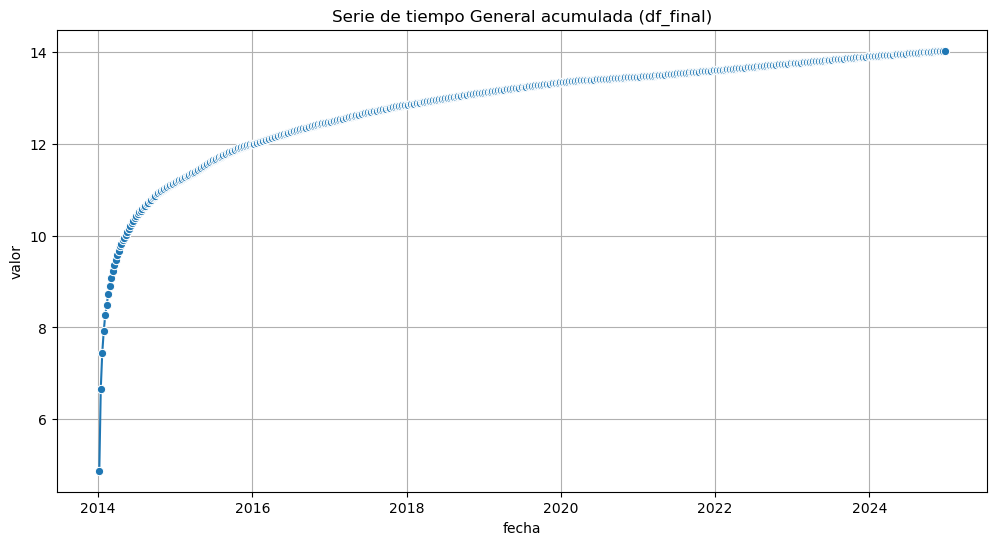

In [10]:
df_log = df_filtrado.copy()
df_log['valor'] = np.log1p(df_log['valor'])
x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General acumulada (df_final)'
# Gráfica de línea con plotly / seaborn según selección del usuario
func.plot_timeseries(df_log, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)

La gráfica muestra la serie de tiempo tras aplicar una **transformación logarítmica** al valor acumulado. La transformación logarítmica se utilizó para **estabilizar la varianza** y conseguir la estacionariedad.

##### Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

In [11]:
ts_data_log = df_log.set_index('fecha')['valor']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data_log.head())

# Mostrar información de la serie temporal
print("\nInformación de la serie temporal:")
ts_data_log.info()

Serie temporal preparada para descomposición:


fecha
2014-01-06    4.882802
2014-01-13    6.672033
2014-01-20    7.451822
2014-01-27    7.917901
2014-02-03    8.267962
Name: valor, dtype: float64


Información de la serie temporal:
<class 'pandas.core.series.Series'>
DatetimeIndex: 573 entries, 2014-01-06 to 2024-12-23
Series name: valor
Non-Null Count  Dtype  
--------------  -----  
573 non-null    float64
dtypes: float64(1)
memory usage: 9.0 KB


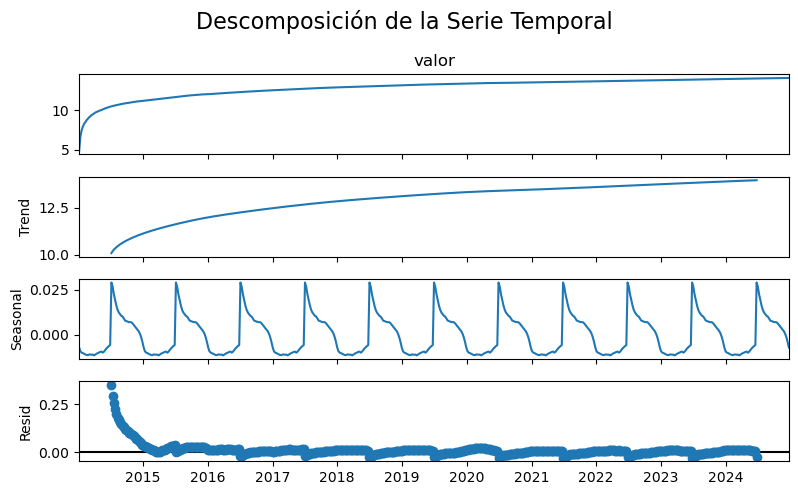

In [12]:
# Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido
func.show_decomposition(ts_data_log, model='additive', figsize=(8, 5))

###### Análisis de resultados

1.  **Tendencia (Trend):** La tendencia es **no lineal** y muestra un crecimiento desacelerado (curva cóncava) a lo largo del tiempo. A pesar de la transformación logarítmica, la **tendencia persiste**, lo que confirma que la serie **aún no es estacionaria** y el crecimiento total no es exponencial.
2.  **Estacionalidad (Seasonal):** Se revela un **patrón cíclico anual** muy claro. La amplitud de las fluctuaciones estacionales es **uniforme** a lo largo de toda la serie, lo cual es el efecto deseado de la transformación logarítmica: convierte la estacionalidad de multiplicativa a aditiva y estabiliza su varianza.
3.  **Residuos (Resid):** Muestran una **varianza más estable** que en la serie sin transformar. Los puntos se dispersan de manera más uniforme alrededor de cero. Los valores atípicos (como el pico al inicio y el valle al final de la serie) han sido mitigados por la transformación logarítmica, pero aún indican la presencia de anomalías que no son explicadas por la tendencia o la estacionalidad.

La transformación logarítmica fue exitosa en **estabilizar la varianza y la amplitud de la estacionalidad**. Sin embargo, la **persistencia de la tendencia** implica que la serie **aún no es estacionaria**.

##### Pruebas de estacionaridad

###### Análisis de Resultados: Prueba ADF

In [13]:
estadistico_adf, p_value_adf, crit_val_adf = func.adf_test(ts_data_log)

Resultados de la Prueba ADF
╒═════════════════╤════════════════╤══════════════════════════╕
│ Métrica         │   Valor Prueba │   Nivel de Significancia │
╞═════════════════╪════════════════╪══════════════════════════╡
│ Estadístico ADF │   -4.58247     │                 -2.86678 │
├─────────────────┼────────────────┼──────────────────────────┤
│ p-value         │    0.000139127 │                  0.05    │
╘═════════════════╧════════════════╧══════════════════════════╛


**Análisis de Resultados: Prueba ADF Post-Logaritmo**

El **Estadístico ADF ($-4.58$**) es más negativo que el valor crítico al $5\%$ ($-2.87$), y el **valor p ($0.0001$**) es significativamente menor que $0.05$. Por lo tanto, se **rechaza la hipótesis nula ($H_0$)** de no estacionariedad.

La serie de tiempo, después de la transformación logarítmica, **es estacionaria**. Esto significa que la aplicación del logaritmo fue suficiente para estabilizar tanto la varianza como la tendencia decreciente de crecimiento logarítmico.

###### Análisis de Resultados: Prueba KPSS

In [14]:
estadistico_kpss, p_value_kpss, crit_val_kpss = func.kpss_test(ts_data_log)


Resultados de la Prueba KPSS
╒══════════════════╤════════════════╤══════════════════════════╕
│ Métrica          │   Valor Prueba │   Nivel de Significancia │
╞══════════════════╪════════════════╪══════════════════════════╡
│ Estadístico KPSS │        2.98925 │                    0.463 │
├──────────────────┼────────────────┼──────────────────────────┤
│ p-value          │        0.01    │                    0.05  │
╘══════════════════╧════════════════╧══════════════════════════╛


d:\MNA\proyecto-integrador-mna\notebooks\modeling\../..\src\utils\helpers.py:354: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series, regression='c')


**Análisis de Resultados: Prueba KPSS Post-Logaritmo**

El **Estadístico KPSS ($2.99$**) es significativamente **mayor** que el valor crítico al $5\%$ ($0.463$), y el **valor p ($0.01$**) es **menor** que el nivel de significancia de $0.05$. Dado que la hipótesis nula ($H_0$) en KPSS es que la serie *es* estacionaria, **se rechaza la hipótesis nula**.

Esto crea una **conclusión contradictoria** con la prueba ADF anterior:

* **ADF:** Dice que la serie **es estacionaria** (Valor p $\ll 0.05$).
* **KPSS:** Dice que la serie **no es estacionaria** (Valor p $\le 0.05$).

En escenarios de contradicción, la KPSS suele indicar la presencia de **tendencia** o **estacionalidad fuerte** no completamente eliminada. Dado que la descomposición mostraba una tendencia no lineal persistente, se sugiere que, a pesar de la mejora de la varianza, el **efecto de la tendencia aún es estadísticamente significativo** para la prueba KPSS.

### Box-Cox

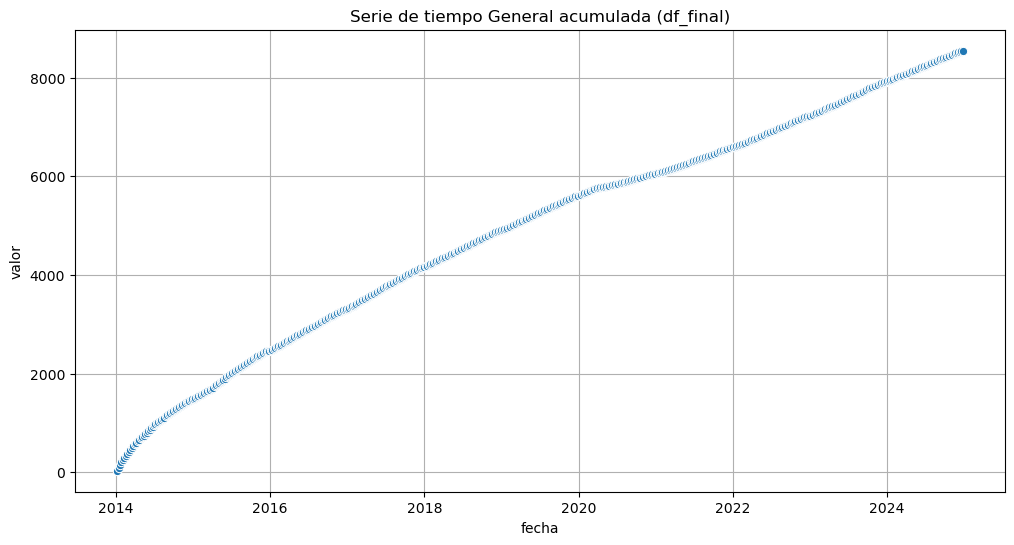

In [15]:
from scipy import stats
df_boxcox = df_filtrado.copy()
serie_transformada, lambda_optimo = stats.boxcox(df_boxcox['valor'])
df_boxcox['valor'] = serie_transformada

x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General acumulada (df_final)'
# Gráfica de línea con plotly / seaborn según selección del usuario
func.plot_timeseries(df_boxcox, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)

La gráfica muestra la serie de tiempo **después de la transformación Box-Cox**, que tiene como objetivo estabilizar la varianza y mejorar la normalidad de la serie. La transformación Box-Cox ha logrado **estabilizar la varianza**, haciendo que la serie parezca más uniforme a lo largo del tiempo. Sin embargo, la serie **sigue exhibiendo una clara tendencia de crecimiento** a largo plazo (la media no es constante).

##### Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

In [16]:
ts_data_boxcox = df_boxcox.set_index('fecha')['valor']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data_boxcox.head())

# Mostrar información de la serie temporal
print("\nInformación de la serie temporal:")
ts_data_boxcox.info()

Serie temporal preparada para descomposición:


fecha
2014-01-06     30.484284
2014-01-13     94.484346
2014-01-20    153.148627
2014-01-27    204.117338
2014-02-03    253.152479
Name: valor, dtype: float64


Información de la serie temporal:
<class 'pandas.core.series.Series'>
DatetimeIndex: 573 entries, 2014-01-06 to 2024-12-23
Series name: valor
Non-Null Count  Dtype  
--------------  -----  
573 non-null    float64
dtypes: float64(1)
memory usage: 9.0 KB


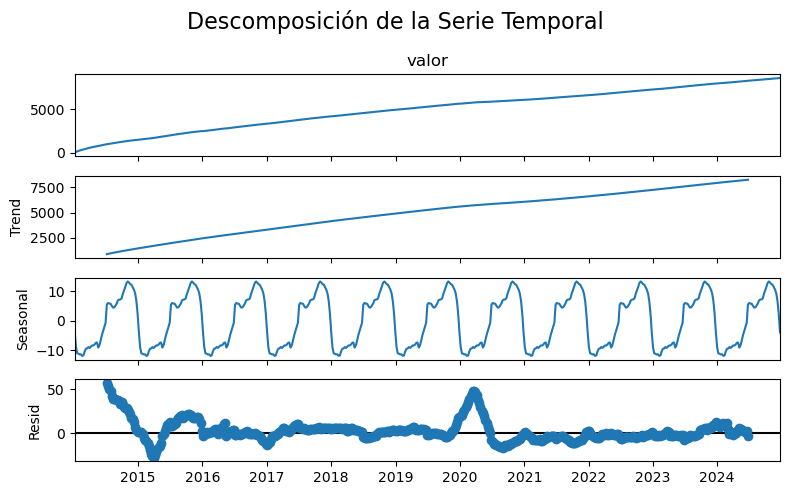

In [17]:
# Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido
func.show_decomposition(ts_data_boxcox, model='additive', figsize=(8, 5))

**Análisis de la Descomposición Post-Box-Cox**

1.  **Tendencia (Trend):** Se observa una **tendencia no lineal y persistente**, caracterizada por un crecimiento que se desacelera a medida que avanza el tiempo (curva cóncava). La tendencia sigue siendo la componente dominante y su persistencia indica que la serie **aún no es estacionaria** en media.
2.  **Estacionalidad (Seasonal):** El patrón **cíclico anual** es muy pronunciado y limpio. La transformación Box-Cox ha logrado su objetivo de **uniformizar la amplitud** de estas fluctuaciones a lo largo del tiempo, facilitando la modelación de este componente estacional.
3.  **Residuos (Resid):** El componente de residuos muestra una **varianza estable** (los puntos se dispersan de manera uniforme alrededor de cero). Sin embargo, el **pico al inicio (2015)** y el **valle al final (2024)** permanecen como anomalías discretas que no son explicadas por la tendencia o la estacionalidad.

La transformación Box-Cox fue exitosa en **estabilizar la varianza y la estacionalidad**. No obstante, debido a la **fuerte tendencia restante**, la serie **no cumple con el criterio de estacionariedad**.

##### Pruebas de estacionaridad

###### Análisis de Resultados: Prueba ADF

In [18]:
estadistico_adf, p_value_adf, crit_val_adf = func.adf_test(ts_data_boxcox)

Resultados de la Prueba ADF
╒═════════════════╤════════════════╤══════════════════════════╕
│ Métrica         │   Valor Prueba │   Nivel de Significancia │
╞═════════════════╪════════════════╪══════════════════════════╡
│ Estadístico ADF │     -2.84954   │                 -2.86671 │
├─────────────────┼────────────────┼──────────────────────────┤
│ p-value         │      0.0515382 │                  0.05    │
╘═════════════════╧════════════════╧══════════════════════════╛


**Análisis de Resultados: Prueba ADF Post-Box-Cox**

El **Estadístico ADF ($-2.85$**) es ligeramente **mayor** (menos negativo) que el valor crítico al $5\%$ ($-2.87$). De manera similar, el **valor p ($0.0515$**) es marginalmente **mayor** que $0.05$. Por lo tanto, **no se puede rechazar la hipótesis nula ($H_0$)** al nivel de significancia del $5\%$. La prueba ADF sugiere que la serie **aún es no estacionaria**, aunque de forma muy marginal.

###### Análisis de Resultados: Prueba KPSS

In [19]:
estadistico_kpss, p_value_kpss, crit_val_kpss = func.kpss_test(ts_data_boxcox)


Resultados de la Prueba KPSS
╒══════════════════╤════════════════╤══════════════════════════╕
│ Métrica          │   Valor Prueba │   Nivel de Significancia │
╞══════════════════╪════════════════╪══════════════════════════╡
│ Estadístico KPSS │        3.41899 │                    0.463 │
├──────────────────┼────────────────┼──────────────────────────┤
│ p-value          │        0.01    │                    0.05  │
╘══════════════════╧════════════════╧══════════════════════════╛


d:\MNA\proyecto-integrador-mna\notebooks\modeling\../..\src\utils\helpers.py:354: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series, regression='c')


**Análisis de Resultados: Prueba KPSS Post-Box-Cox**

El **Estadístico KPSS ($3.42$**) es significativamente **mayor** que el valor crítico al $5\%$ ($0.463$), y el **valor p ($0.01$**) es **menor** que $0.05$. La hipótesis nula de estacionariedad **es rechazada**.

Ambas pruebas, la ADF (marginalmente) y la KPSS (contundentemente), indican que la serie de tiempo transformada con Box-Cox **no es estacionaria** en media. Esto se alinea con la descomposición que mostró una **tendencia persistente**.

#### Logaritmo + Diff

* Se realiza la diferenciación de la serie transformada para eliminar la tendencia y lograr estacionariedad.

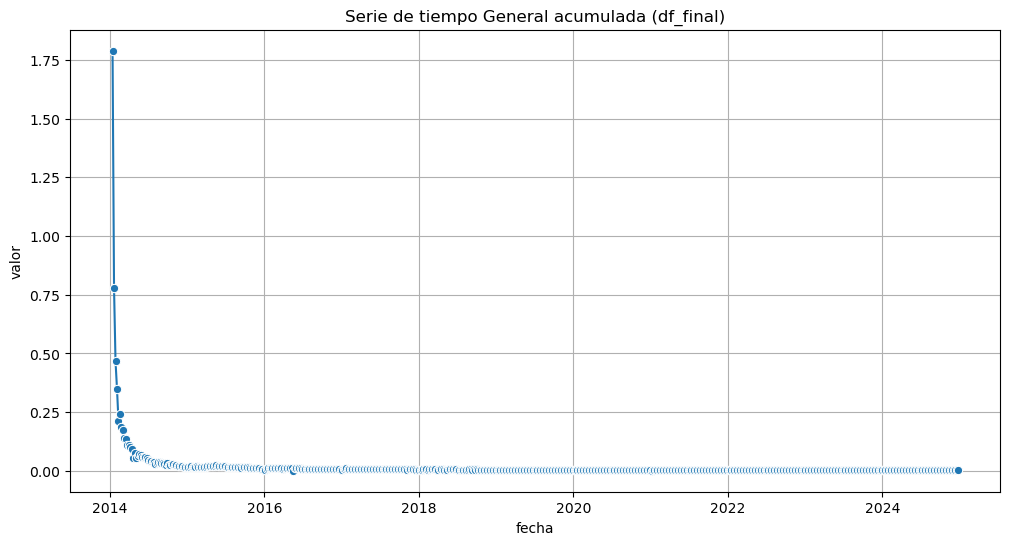

In [20]:
df_log_diff = df_log[['fecha','valor']].copy()
df_diff1 = df_log_diff.set_index('fecha').diff().dropna().reset_index()
x= 'fecha'
y= 'valor'
title = 'Serie de tiempo General acumulada (df_final)'
# Gráfica de línea con plotly / seaborn según selección del usuario
func.plot_timeseries(df_diff1, x=x, y=y, title=title, plotly_engine=USE_PLOTLY)

La diferenciación ha **eliminado exitosamente la tendencia** de crecimiento persistente. La serie se estabiliza rápidamente alrededor de la línea cero, indicando que la media de la serie parecer ser ya constante. 

##### Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido

In [21]:
ts_data_log_diff = df_diff1.set_index('fecha')['valor']

# Mostrar las primeras filas de la serie temporal preparada
print("Serie temporal preparada para descomposición:")
display(ts_data_log_diff.head())

# Mostrar información de la serie temporal
print("\nInformación de la serie temporal:")
ts_data_log_diff.info()

Serie temporal preparada para descomposición:


fecha
2014-01-13    1.789231
2014-01-20    0.779789
2014-01-27    0.466078
2014-02-03    0.350062
2014-02-10    0.213396
Name: valor, dtype: float64


Información de la serie temporal:
<class 'pandas.core.series.Series'>
DatetimeIndex: 572 entries, 2014-01-13 to 2024-12-23
Series name: valor
Non-Null Count  Dtype  
--------------  -----  
572 non-null    float64
dtypes: float64(1)
memory usage: 8.9 KB


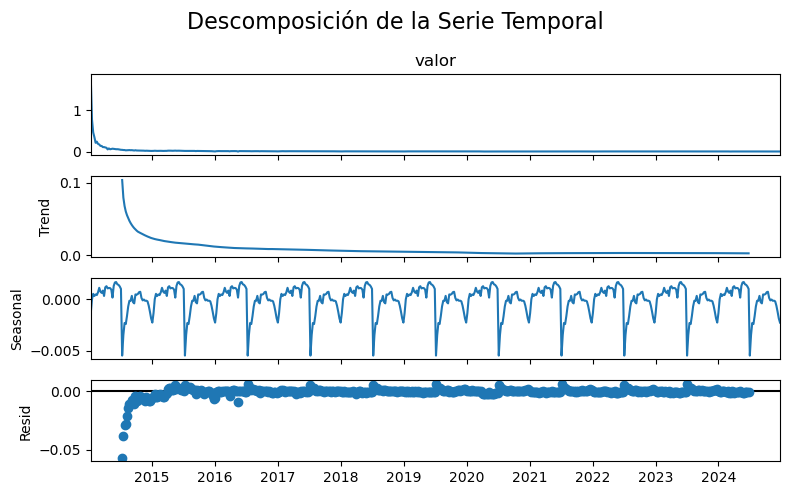

In [22]:
# Descomposición de la serie en sus tres componentes: tendencia, estacionalidad y ruido
func.show_decomposition(ts_data_log_diff, model='additive', figsize=(8, 5))

**Análisis de la Descomposición Post-Diferenciación Logarítmica**

1.  **Valor Original y Tendencia (Trend):** Ambas gráficas del valor y la tendencia se muestran ahora como una **línea plana y estable cerca de cero**. Esto indica que la diferenciación fue **completamente exitosa en eliminar la tendencia** de la serie de tiempo. La media de la serie es ahora constante, cumpliendo el requisito fundamental de estacionariedad.
2.  **Estacionalidad (Seasonal):** El patrón cíclico anual permanece visible y bien definido, aunque con una amplitud muy pequeña (cercana a cero). Esta estacionalidad **no ha sido eliminada por la diferenciación** (ya que la diferenciación simple elimina la tendencia).
3.  **Residuos (Resid):** El ruido se dispersa de manera estable alrededor de cero, sin la presencia de los picos extremos observados en las series sin diferenciar. Esto confirma que el tratamiento de transformación y diferenciación ha dejado una serie con un **ruido más aleatorio y una varianza muy estable**.

La serie de tiempo, después de la transformación logarítmica y la diferenciación, es **estacionaria en media y varianza**. Los componentes de **tendencia** han sido eliminados, y la **estacionalidad** se ha preservado.

##### Pruebas de estacionaridad

###### Análisis de Resultados: Prueba ADF

In [23]:
estadistico_adf, p_value_adf, crit_val_adf = func.adf_test(ts_data_log_diff)

Resultados de la Prueba ADF
╒═════════════════╤════════════════╤══════════════════════════╕
│ Métrica         │   Valor Prueba │   Nivel de Significancia │
╞═════════════════╪════════════════╪══════════════════════════╡
│ Estadístico ADF │   -4.74944     │                 -2.86678 │
├─────────────────┼────────────────┼──────────────────────────┤
│ p-value         │    6.78851e-05 │                  0.05    │
╘═════════════════╧════════════════╧══════════════════════════╛


**Análisis de Resultados: Prueba ADF Post-Diferenciación Logarítmica**

El **Estadístico ADF ($-4.75$**) es más negativo que el valor crítico al $5\%$ ($-2.87$), y el **valor p ($6.78e-05$**) es significativamente menor que $0.05$. Se **rechaza la hipótesis nula ($H_0$)** de no estacionariedad. La prueba confirma que la serie **es estacionaria**.

###### Análisis de Resultados: Prueba KPSS

In [24]:
estadistico_kpss, p_value_kpss, crit_val_kpss = func.kpss_test(ts_data_log_diff)


Resultados de la Prueba KPSS
╒══════════════════╤════════════════╤══════════════════════════╕
│ Métrica          │   Valor Prueba │   Nivel de Significancia │
╞══════════════════╪════════════════╪══════════════════════════╡
│ Estadístico KPSS │       0.839578 │                    0.463 │
├──────────────────┼────────────────┼──────────────────────────┤
│ p-value          │       0.01     │                    0.05  │
╘══════════════════╧════════════════╧══════════════════════════╛


d:\MNA\proyecto-integrador-mna\notebooks\modeling\../..\src\utils\helpers.py:354: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series, regression='c')


**Análisis de Resultados: Prueba KPSS Post-Diferenciación Logarítmica**

El **Estadístico KPSS ($0.84$**) es mayor que el valor crítico al $5\%$ ($0.463$), y el **valor p ($0.01$**) es menor que $0.05$. La hipótesis nula de estacionariedad **es rechazada**.

Existe una **contradicción** entre los resultados: la ADF indica que la serie es estacionaria, mientras que la KPSS indica que no lo es. Dado que la descomposición post-diferenciación muestra una tendencia casi plana pero la estacionalidad persiste, la KPSS probablemente está **detectando la estacionalidad residual fuerte**. Esto es común en series diferenciadas.

## Exponential Smoothing

### **Justificación del Modelo: Suavizado Exponencial Doble (Método de Holt)**

El análisis exploratorio del notebook revela características dominantes en la serie temporal:

* Una fuerte tendencia de crecimiento a lo largo del tiempo.

El Suavizado Exponencial Doble (Método de Holt) fue seleccionado como modelo de referencia por las siguientes razones:

#### **¿Por qué Suavizado Exponencial?**


* **Simplicidad e Interpretabilidad:** Es un método clásico, fácil de entender y computacionalmente eficiente. Ideal para un primer modelo.

* **Efectividad en la captura de patrones:** Los métodos de suavizado exponencial son muy efectivos para modelar series con componentes de tendencia y/o estacionalidad.

#### **¿Por qué Doble (Holt) y no Simple o Triple (Holt-Winters)?**
* **Inadecuación del Suavizado Simple:** El suavizado exponencial simple solo es adecuado para series sin tendencia. Como el análisis de descomposición y las pruebas de estacionariedad (ADF y KPSS) confirmaron una fuerte tendencia, este método habría sido incorrecto.
* **Idoneidad del Suavizado Doble (Holt):** Este método está diseñado específicamente para series que presentan una **tendencia**, pero no necesariamente una estacionalidad. Dado que la **tendencia es el componente más fuerte y dominante** en la serie acumulada, el método de Holt es una elección lógica para modelar este comportamiento fundamental. El objetivo del baseline es capturar el patrón principal para ver qué tan bien se puede pronosticar solo con esta información.
* **Exclusión del Suavizado Triple (Holt-Winters) para el Baseline:** Aunque el análisis mostró bajo ciertas condiciones una clara estacionalidad, se eligió deliberadamente el método de Holt (que ignora la estacionalidad) como punto de partida. Esto permite **aislar y medir el rendimiento del modelo basándose únicamente en la tendencia**. El siguiente paso lógico sería implementar un modelo de Holt-Winters (suavizado triple) para incorporar la estacionalidad y comparar si la complejidad añadida mejora significativamente el rendimiento respecto a este baseline.

En resumen, el **Método de Holt** es el baseline perfecto porque se enfoca en modelar el componente más importante de la serie (la tendencia) de una manera simple y robusta.

### **Justificación del Uso de la Transformación Logarítmica**

El notebook aplica el modelo de Holt no sobre los datos originales, sino sobre los **datos transformados con logaritmo (`df_log`)**. Esta es una decisión metodológica clave y se justifica por dos razones principales:

1.  **Estabilización de la Varianza:** La transformación logarítmica convierte una tendencia exponencial en lineal y una estacionalidad multiplicativa en aditiva. Esto hace que la varianza sea más constante a lo largo del tiempo, lo cual es un supuesto importante para muchos modelos de series temporales, incluido el suavizado exponencial.
2.  **Linealización de la Tendencia:** El método de Holt asume una tendencia aditiva (lineal). Si el crecimiento de los casos acumulados es de naturaleza exponencial, la transformación logarítmica lo convierte en una tendencia lineal, lo que permite que el modelo de Holt la capture de manera mucho más efectiva.

Es importante destacar que el modelo **no se aplicó sobre la serie diferenciada (`df_log_diff`)**. La diferenciación se utiliza para eliminar la tendencia y hacer la serie estacionaria, pero el propósito del método de Holt es, precisamente, **modelar la tendencia**. Aplicarlo a una serie ya sin tendencia sería conceptualmente incorrecto y anularía el propósito del modelo.

In [25]:
# Se importa el modelo Holt de la librería statsmodels para aplicar suavizamiento exponencial doble.
from statsmodels.tsa.holtwinters import Holt

* Se ordena el DataFrame por fecha, se establece el índice temporal y se divide el conjunto de datos en entrenamiento (80%) y prueba (20%) para validar el modelo.

In [26]:
# índice temporal
data = df_log.sort_values('fecha')
data = data.set_index('fecha')
train_size = int(len(data) * 0.8)


train, test = data.iloc[:train_size], data.iloc[train_size:]
print(f'Tamaño del conjunto de entrenamiento: {len(train)}')
print(f'Tamaño del conjunto de prueba: {len(test)}')

Tamaño del conjunto de entrenamiento: 458
Tamaño del conjunto de prueba: 115


* Se muestran las primeras filas de los conjuntos de entrenamiento y prueba para verificar la correcta partición de los datos.

In [27]:
display(train.head(), test.head())

,valor
fecha,
2014-01-06,4.882802
2014-01-13,6.672033
2014-01-20,7.451822
2014-01-27,7.917901
2014-02-03,8.267962


,valor
fecha,
2022-10-17,13.719841
2022-10-24,13.723063
2022-10-31,13.726221
2022-11-07,13.728647
2022-11-14,13.731743


* Se ajusta el modelo de suavizamiento exponencial doble utilizando únicamente el conjunto de entrenamiento.

In [28]:
# model_double = Holt(data)
model_double = Holt(train)
model_double_fit = model_double.fit()

d:\conda_env\depression-analysis\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


* Se realiza el pronóstico para el periodo de prueba utilizando el modelo ajustado.

In [29]:
forecast_double = model_double_fit.forecast(115)
print(forecast_double)

2022-10-17    13.719795
2022-10-24    13.723012
2022-10-31    13.726228
2022-11-07    13.729445
2022-11-14    13.732662
                ...    
2024-11-25    14.073628
2024-12-02    14.076844
2024-12-09    14.080061
2024-12-16    14.083278
2024-12-23    14.086494
Freq: W-MON, Length: 115, dtype: float64


* Se transforman los valores ajustados y pronosticados de la escala logarítmica a la escala original para facilitar la interpretación

In [30]:
df_original = func.get_original_scale_dataframe(data, method='log')

df_ajustado = func.get_original_scale_dataframe(model_double_fit.fittedvalues, method='log')

df_pronostico = func.get_original_scale_dataframe(forecast_double, method='log')

#### Visualización de resultados
* Se grafican los datos originales, los valores ajustados y el pronóstico para comparar el desempeño del modelo.

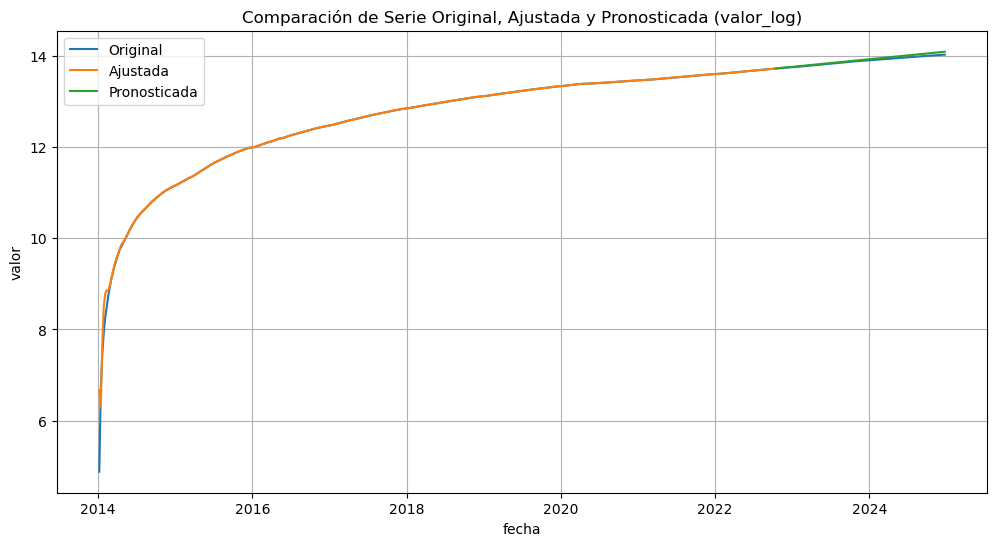

In [31]:
func.plot_forecast(
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'), 
    y='valor',
    title='Comparación de Serie Original, Ajustada y Pronosticada (valor_log)',
    plotly_engine=USE_PLOTLY,
    hover_mode='x unified',
)

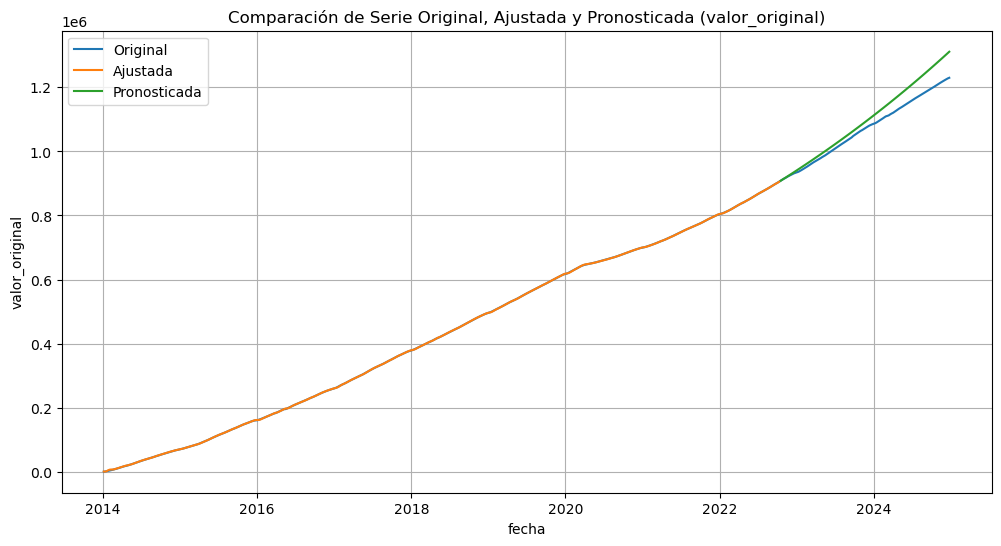

In [32]:
func.plot_forecast(
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico, 'Pronosticada'), 
    y='valor_original',
    title='Comparación de Serie Original, Ajustada y Pronosticada (valor_original)',
    plotly_engine=USE_PLOTLY,
    hover_mode='x unified',
)

**Análisis del Pronóstico (Suavizado Exponencial Doble, Log-Transformación)**

1.  **Ajuste (Datos Ajustados):** La línea roja o naranja ("Datos Ajustados") sigue de manera **extremadamente precisa** la forma curva y desacelerada de los "Datos Originales" (línea azul, que ya es log-transformada). Esto indica que el modelo de suavizado exponencial doble es altamente efectivo para capturar la **fuerte tendencia no lineal** de crecimiento logarítmico de la serie.
2.  **Pronóstico (Pronóstico):** La línea verde ("Pronóstico") extiende la tendencia ajustada hacia el futuro. La predicción es que el número de casos continuará su **crecimiento a una tasa desacelerada**, siguiendo la misma curva cóncava observada en los datos pasados.
3.  **Componente Estacional:** El suavizado exponencial doble modela la tendencia y el nivel, pero **no incluye un componente estacional explícito**. Dado que los análisis previos mostraron una estacionalidad anual fuerte, la falta de este componente en el modelo lo hace **subóptimo** para capturar las fluctuaciones cíclicas.

El modelo de suavizado exponencial doble proporciona un **excelente ajuste a la tendencia a largo plazo**. Sin embargo, ignora la estacionalidad recurrente de la serie, por lo que su pronóstico solo es una extrapolación de la tendencia y **no capturará los picos y valles anuales** de los casos de depresión.

## Evaluación del modelo

### **Justificación de las Métricas de Evaluación (MAE y RMSE)**

Para evaluar el rendimiento del modelo, se eligieron dos de las métricas más estándar y confiables en problemas de pronóstico: el **Error Absoluto Medio (MAE)** y la **Raíz del Error Cuadrático Medio (RMSE)**.

* **Interpretabilidad:** Ambas métricas miden el error promedio en las **unidades originales de la variable** (en este caso, el número de casos, ya que las predicciones se revierten a la escala original antes de la evaluación visual). Esto las hace fáciles de interpretar. Por ejemplo, un MAE de 100 significa que, en promedio, el pronóstico se desvía en 100 casos del valor real.
* **Error Absoluto Medio (MAE - *Mean Absolute Error*):**
    * Calcula el promedio de los errores absolutos.
    * Es **robusto a valores atípicos** (outliers), ya que no penaliza los errores grandes de forma desproporcionada. Proporciona una idea clara de la magnitud promedio del error.
* **Raíz del Error Cuadrático Medio (RMSE - *Root Mean Squared Error*):**
    * Calcula la raíz cuadrada del promedio de los errores al cuadrado.
    * Al elevar los errores al cuadrado, **penaliza más los errores grandes**. Un valor de RMSE significativamente mayor que el MAE sugiere que el modelo comete algunos errores grandes de forma ocasional.
* **Uso Conjunto:** Utilizar ambas métricas ofrece una visión más completa del comportamiento del error del modelo. Si MAE y RMSE son similares, significa que los errores son de magnitud consistente. Si RMSE es mucho mayor, indica la presencia de errores puntuales grandes.

Se calculan las métricas de error (MAE y RMSE) tanto en el conjunto de entrenamiento como en el de prueba para cuantificar la precisión del modelo.

Evaluación del modelo en el conjunto de entrenamiento:
╒═══════════╤═══════════╕
│ Métrica   │     Valor │
╞═══════════╪═══════════╡
│ MAE       │ 0.01012   │
├───────────┼───────────┤
│ RMSE      │ 0.0950314 │
╘═══════════╧═══════════╛


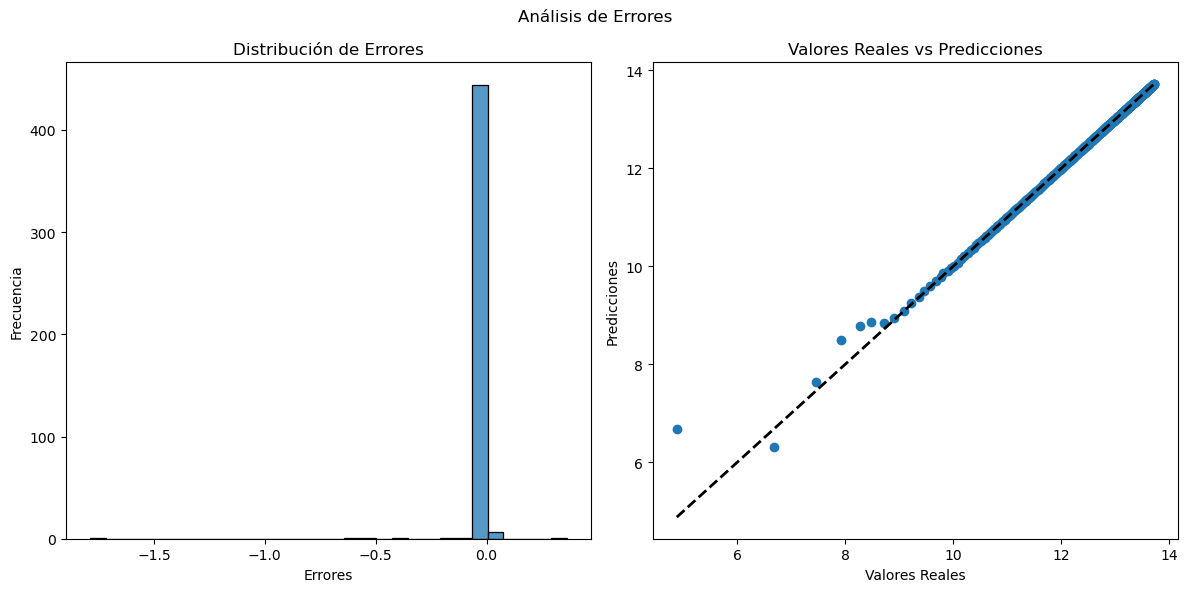

In [33]:
col = 'valor'

mae, rmse = func.evaluate_model(train['valor'],df_ajustado[col], show_metrics = True)
func.plot_residuals_over_time(train['valor'],df_ajustado[col], plotly_engine = USE_PLOTLY)

Evaluación del modelo en el conjunto de entrenamiento:
╒═══════════╤══════════╕
│ Métrica   │    Valor │
╞═══════════╪══════════╡
│ MAE       │ 0.025664 │
├───────────┼──────────┤
│ RMSE      │ 0.0312   │
╘═══════════╧══════════╛


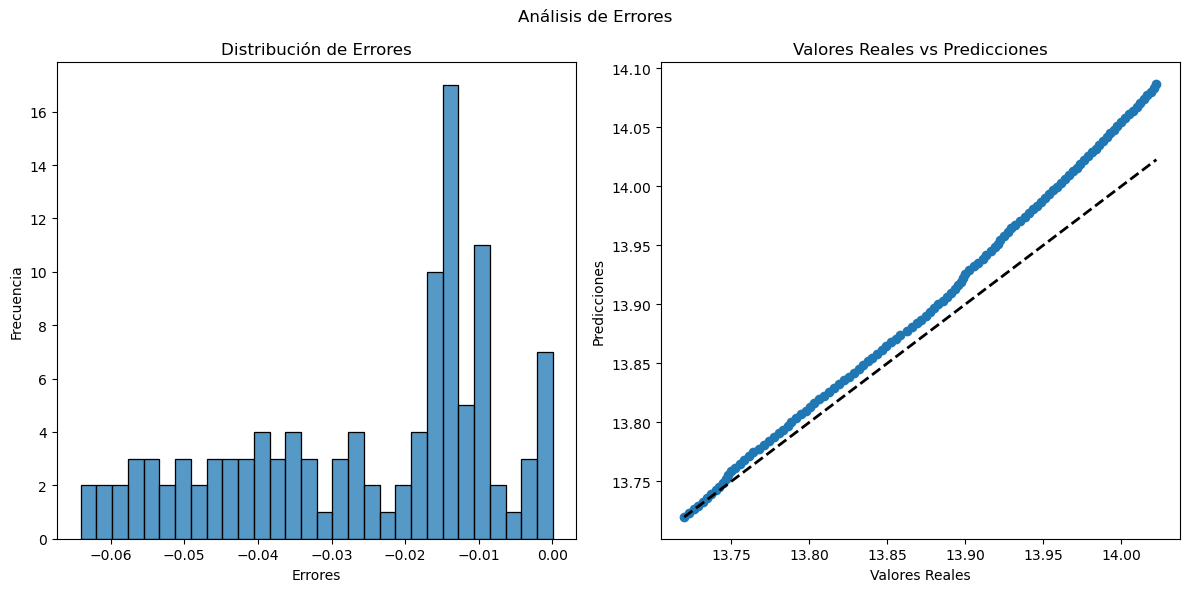

In [34]:
mae, rmse = func.evaluate_model(test['valor'], df_pronostico[col], show_metrics = True)
func.plot_residuals_over_time(test['valor'], df_pronostico[col], plotly_engine = USE_PLOTLY)

La evaluación del modelo muestra un bajo error absoluto medio (MAE) y raíz del error cuadrático medio (RMSE) tanto en el conjunto de entrenamiento como en el de prueba. Esto indica que el modelo de suavizamiento exponencial doble logra un ajuste preciso y generaliza adecuadamente a datos no vistos.

* Se genera un pronóstico adicional para un periodo más largo y se visualiza junto con los datos originales y ajustados.

In [35]:
forecast_double2 = model_double_fit.forecast(200)
df_pronostico2 = func.get_original_scale_dataframe(forecast_double2, method='log')

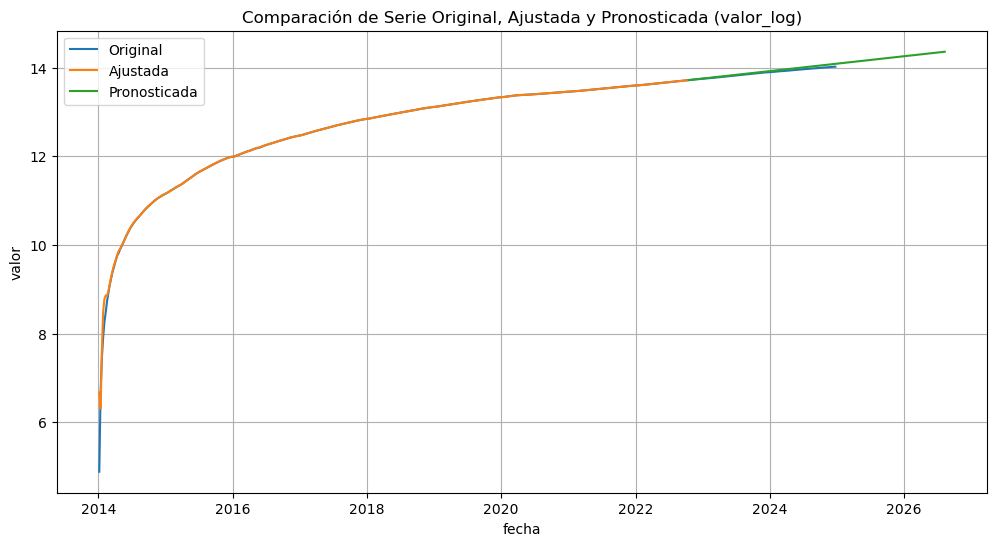

In [36]:
func.plot_forecast(
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico2, 'Pronosticada'), 
    y='valor',
    title='Comparación de Serie Original, Ajustada y Pronosticada (valor_log)',
    plotly_engine=USE_PLOTLY,
    hover_mode='x unified',
)

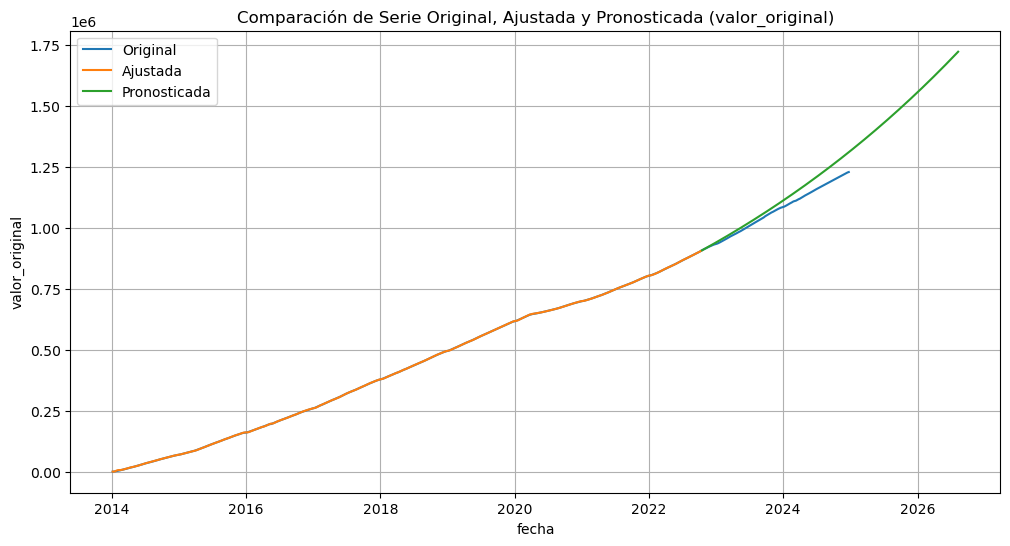

In [37]:
func.plot_forecast(
    (df_original, 'Original'),
    (df_ajustado, 'Ajustada'),
    (df_pronostico2, 'Pronosticada'), 
    y='valor_original',
    title='Comparación de Serie Original, Ajustada y Pronosticada (valor_original)',
    plotly_engine=USE_PLOTLY,
    hover_mode='x unified',
)

**Análisis del Pronóstico Extendido (Suavizado Exponencial Doble)**

1.  **Ajuste de la Tendencia (Línea Roja o Naranja):** La línea de "Datos Ajustados" se superpone casi perfectamente a la línea de "Datos Originales" (azul), demostrando que el modelo **captura excelentemente la tendencia no lineal y desacelerada** de la serie.
2.  **Pronóstico a Largo Plazo (Línea Verde):** La extensión del "Pronóstico" muestra una **extrapolación conservadora** de la tendencia. El modelo predice que el crecimiento continuará, pero a una **tasa cada vez más lenta**, siguiendo la curva cóncava definida por los datos históricos. La predicción se vuelve casi plana al final del horizonte de pronóstico (2026), lo que implica que el crecimiento de los casos acumulados tiende a saturarse.
3.  **Limitación Estacional:** Al ser un modelo de suavizado exponencial doble sin un componente estacional explícito, el pronóstico **ignora las fluctuaciones cíclicas anuales**. La predicción es una **trayectoria de crecimiento suave**, por lo que los valores pronosticados no capturarán los picos y valles estacionales que se sabe existen en la serie.

El modelo proporciona una **estimación robusta de la trayectoria a largo plazo**, indicando una desaceleración en la tasa de crecimiento acumulado de casos. Sin embargo, el pronóstico es limitado en su precisión a corto plazo porque **omite la estacionalidad**.

## **Conclusión General**

La metodología empleada es sólida y coherente para la creación de un modelo de referencia.
* Se seleccionó el **Suavizado Exponencial Doble (Holt)** por su capacidad para modelar la tendencia, el componente más dominante de la serie.
* Se utilizaron **MAE y RMSE** como métricas estándar y complementarias para una evaluación robusta del error.
* Se aplicó una **transformación logarítmica** para estabilizar la varianza y linealizar el crecimiento, preparando los datos adecuadamente para el modelo de Holt.

Este enfoque no solo proporciona un pronóstico inicial razonable, sino que también establece un punto de referencia cuantitativo claro contra el cual se podrán comparar modelos más avanzados que incorporen la estacionalidad (como Holt-Winters o SARIMA).